In [61]:
import json
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [62]:
with open("data/isoflops_curves.json", "r") as f:
    runs = json.load(f)
    
print(runs[0])

{'parameters': 49999999, 'compute_budget': 6e+18, 'final_loss': 7.192784500319437}


In [63]:
# Organize the runs by the compute budget
compute_budget_runs = defaultdict(list)
for run in runs:
    n_params = run["parameters"]
    compute_budget = run["compute_budget"]
    loss = run["final_loss"]
    compute_budget_runs[compute_budget].append((n_params, loss))

compute_budget_runs[6e+18]

[(49999999, 7.192784500319437),
 (78730505, 6.750171320661809),
 (123969849, 6.406639752150447),
 (195204177, 6.154368665155925),
 (307370470, 5.987783393573661),
 (483988649, 5.903434642394701),
 (762093419, 5.899930270214304),
 (1200000000, 5.977918696411691)]

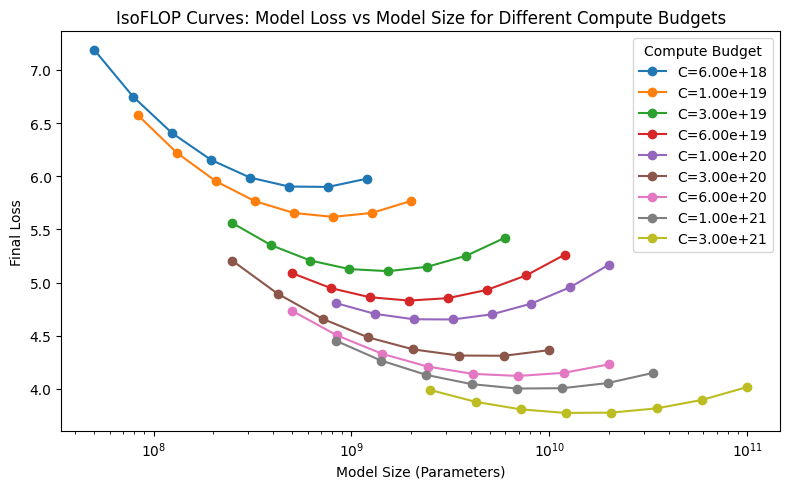

In [64]:
# Plot the isoflop curves: x = model size, y = model loss, curves for each compute budget
plt.figure(figsize=(8, 5))
for compute_budget, run_list in compute_budget_runs.items():
    n_params = [n for n, l in run_list]
    losses = [l for n, l in run_list]
    # Sort for smoother lines
    sorted_pairs = sorted(zip(n_params, losses))
    n_sorted, l_sorted = zip(*sorted_pairs)
    plt.plot(n_sorted, l_sorted, marker='o', label=f"C={int(compute_budget):.2e}")

plt.xlabel("Model Size (Parameters)")
plt.ylabel("Final Loss")
plt.title("IsoFLOP Curves: Model Loss vs Model Size for Different Compute Budgets")
plt.legend(title="Compute Budget", loc="best")
plt.xscale("log")
plt.tight_layout()
plt.show()

In [19]:
# Find the model size with lowest loss for each compute budget
c_values = []
n_opt_values = []
d_opt_values = []

for compute_budget, runs in compute_budget_runs.items():
    n_opt = min(runs, key=lambda x: x[1])[0]
    d_opt = compute_budget / (6 * n_opt)
    c_values.append(compute_budget)
    n_opt_values.append(n_opt)
    d_opt_values.append(d_opt)

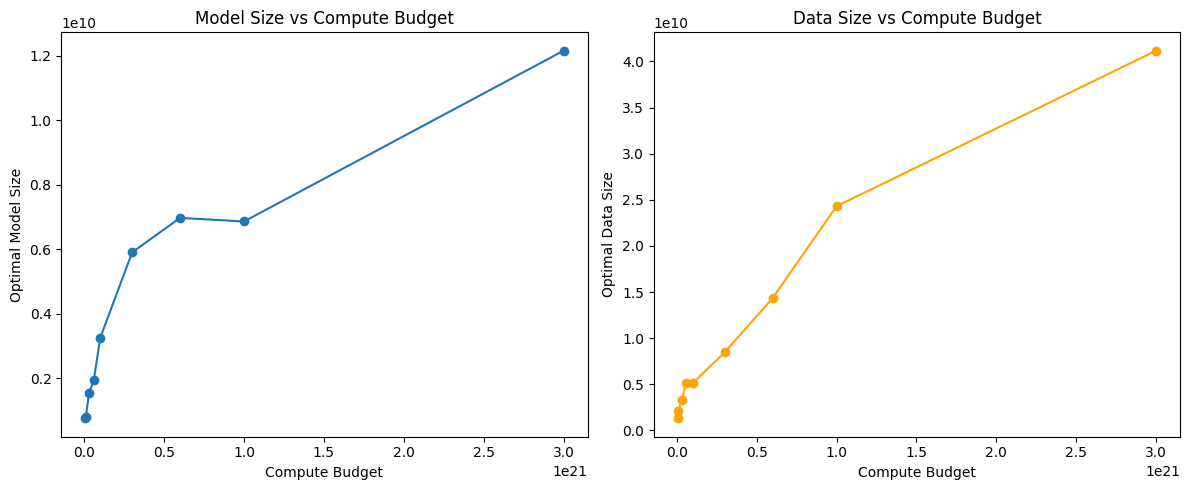

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
axs[0].plot(c_values, n_opt_values, marker='o')
axs[0].set_title("Model Size vs Compute Budget")
axs[0].set_xlabel("Compute Budget")
axs[0].set_ylabel("Optimal Model Size")

axs[1].plot(c_values, d_opt_values, marker='o', color='orange')
axs[1].set_title("Data Size vs Compute Budget")
axs[1].set_xlabel("Compute Budget")
axs[1].set_ylabel("Optimal Data Size")

plt.tight_layout()
plt.show()

In [30]:
# fit N_opt proportional to C^a and D_opt proportional to C^b
def power_law(C, coeff, a):
    return coeff * C ** a

(N_coeff, N_a), _ = curve_fit(power_law, c_values, n_opt_values)
(D_coeff, D_a), _ = curve_fit(power_law, c_values, d_opt_values)

print(f"N_opt scaling law: coeff = {N_coeff}, a = {N_a}")
print(f"D_opt scaling law: coeff = {D_coeff}, b = {D_a}")

N_opt scaling law: coeff = 25.79298341436188, a = 0.4038113776594036
D_opt scaling law: coeff = 0.006337587731933184, b = 0.5967707099325951


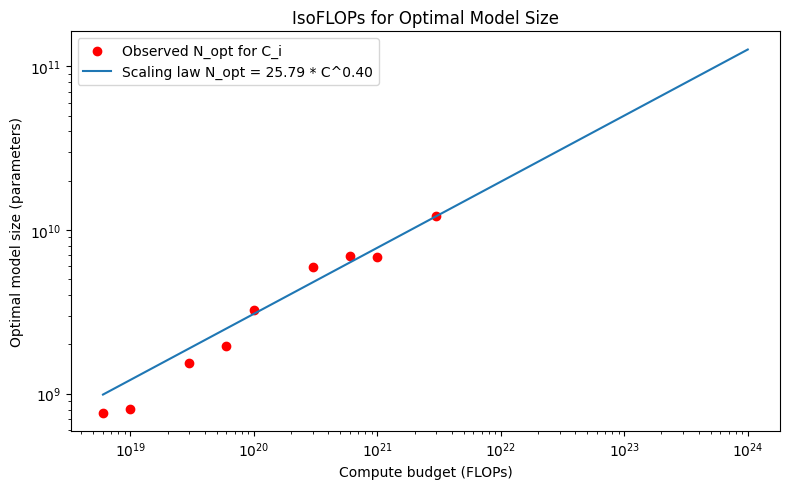

In [65]:
C_logscale = np.logspace(start=np.log10(min(c_values)), stop=24, num=200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(c_values, n_opt_values, color="red", label="Observed N_opt for C_i")
ax.plot(C_logscale, power_law(C_logscale, N_coeff, N_a), label=f"Scaling law N_opt = {N_coeff:.2f} * C^{N_a:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute budget (FLOPs)")
ax.set_ylabel("Optimal model size (parameters)")
ax.set_title("IsoFLOPs for Optimal Model Size")
ax.legend()
plt.tight_layout()
plt.savefig("writeup/figures/isoflops_model.png")
plt.show()

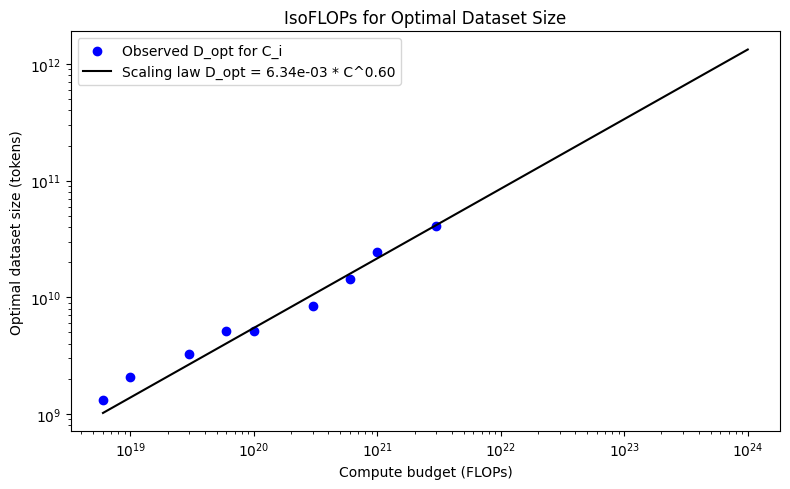

In [58]:
# Plot the scaling law fit for the dataset size (D_opt) on log-log axes, similar to the model size plot above.

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(c_values, d_opt_values, color="blue", label="Observed D_opt for C_i")
ax.plot(C_logscale, power_law(C_logscale, D_coeff, D_a), label=f"Scaling law D_opt = {D_coeff:.2e} * C^{D_a:.2f}", color="black")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute budget (FLOPs)")
ax.set_ylabel("Optimal dataset size (tokens)")
ax.set_title("IsoFLOPs for Optimal Dataset Size")
ax.legend()
plt.tight_layout()
plt.savefig("writeup/figures/isoflops_dataset.png")
plt.show()

In [60]:
# Predictions
for target_C in [1e23, 1e24]:
    N_pred = power_law(target_C, N_coeff, N_a)
    D_pred = power_law(target_C, D_coeff, D_a)
    print(f"For C = {target_C:.2e}:")
    print(f"  Predicted model size: N = {N_pred:.2e}")
    print(f"  Predicted dataset size: D = {D_pred:.2e}")
    print(f"  Ratio D/N: {D_pred/N_pred:.2f}")
    print()

For C = 1.00e+23:
  Predicted model size: N = 5.00e+10
  Predicted dataset size: D = 3.37e+11
  Ratio D/N: 6.74

For C = 1.00e+24:
  Predicted model size: N = 1.27e+11
  Predicted dataset size: D = 1.33e+12
  Ratio D/N: 10.51

